# Analysis of Official Experimental Results of GRPO 
This notebook is used to analyze the `formal_validation_history.csv` file from the formal experiment, and it focuses on answering the following questions: 
- Does the reward really increase with training?
- What components mainly contribute to the increase in reward?
- Are the training/validation curves stable?
- Are the Recall/MRR/Full Evidence in the validation set simultaneously improving?
- Is there any obvious reward hacking or saturation of long-term gains? 
Explanation: The table represents the **validation history**, not the complete training log for each batch.
>Attention:
> - The main graph here essentially shows "changes in the validation set over checkpoints";
> - The standard deviation in the "stability graph" is approximated using **rolling std (rolling standard deviation)** instead of the standard deviation of rewards within each group.

> 说明：表格是 **validation history**，不是逐 batch 的完整训练日志。
> 因此：
> - 这里的主图本质上是“**验证集随 checkpoint 的变化**”；
> - “稳定性图”中的标准差采用 **rolling std（滚动标准差）** 近似，而不是组内 reward std。

In [21]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
plt.rcParams['figure.figsize'] = (8, 4.8)
plt.rcParams['axes.unicode_minus'] = False
DATA_PATH = Path('formal_validation_history.csv')
df = pd.read_csv(DATA_PATH)
df['kl'] = pd.to_numeric(df['kl'], errors='coerce')
for col in df.columns:
    if col != 'kl':
        df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.sort_values('step').reset_index(drop=True)
df.head()

,step,reward,sentence_recall@5,sentence_recall@10,page_recall@5,page_recall@10,full_evidence@10,mrr,reward_doc,reward_sent,reward_full,reward_mrr,query_len,claim_len,query_growth_ratio,kl
0,10,1.351070,0.487,0.559,0.557,0.622,0.509,0.382850,0.2785,0.487,0.509,0.076570,10.090,8.143,1.262971,NaN
1,20,1.356620,0.489,0.562,0.563,0.627,0.509,0.385602,0.2815,0.489,0.509,0.077120,10.084,8.143,1.261634,NaN
2,30,1.357594,0.492,0.559,0.563,0.620,0.507,0.385471,0.2815,0.492,0.507,0.077094,10.134,8.143,1.268933,NaN
3,40,1.389774,0.501,0.576,0.575,0.639,0.523,0.391368,0.2875,0.501,0.523,0.078274,10.016,8.143,1.253193,NaN
4,50,1.418948,0.516,0.586,0.582,0.643,0.532,0.399739,0.2910,0.516,0.532,0.079948,9.904,8.143,1.238773,NaN


## 1. Data Overview
数据概览

In [2]:
summary = pd.DataFrame({
    'min': df.min(numeric_only=True),
    'max': df.max(numeric_only=True),
    'last': df.iloc[-1],
}).round(4)
summary

,min,max,last
step,10.0000,200.0000,200.0000
reward,1.3511,1.7039,1.7035
sentence_recall@5,0.4870,0.6160,0.6160
sentence_recall@10,0.5590,0.7000,0.6990
page_recall@5,0.5570,0.7050,0.7050
page_recall@10,0.6200,0.7750,0.7750
full_evidence@10,0.5070,0.6370,0.6360
mrr,0.3828,0.4954,0.4948
reward_doc,0.2785,0.3525,0.3525
reward_sent,0.4870,0.6160,0.6160


In [3]:
start = df.iloc[0]
end = df.iloc[-1]

key_metrics = [
    'reward', 'sentence_recall@5', 'sentence_recall@10',
    'page_recall@5', 'page_recall@10', 'full_evidence@10', 'mrr'
]

delta_rows = []
for m in key_metrics:
    delta_rows.append({
        'metric': m,
        'start': start[m],
        'end': end[m],
        'absolute_gain': end[m] - start[m],
        'relative_gain_%': ((end[m] - start[m]) / start[m] * 100) if start[m] != 0 else np.nan,
    })

delta_df = pd.DataFrame(delta_rows).round(4)
delta_df

,metric,start,end,absolute_gain,relative_gain_%
0,reward,1.3511,1.7035,0.3524,26.0817
1,sentence_recall@5,0.4870,0.6160,0.1290,26.4887
2,sentence_recall@10,0.5590,0.6990,0.1400,25.0447
3,page_recall@5,0.5570,0.7050,0.1480,26.5709
4,page_recall@10,0.6220,0.7750,0.1530,24.5981
5,full_evidence@10,0.5090,0.6360,0.1270,24.9509
6,mrr,0.3828,0.4948,0.1119,29.2304


## 2. Total Trend of Reward 

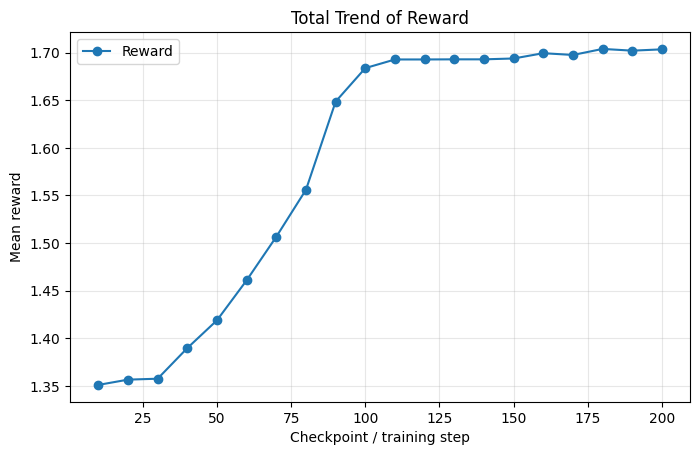

In [24]:
plot_df = df.copy()
fig, ax = plt.subplots()
ax.plot(plot_df['step'], plot_df['reward'], marker='o', label='Reward')
ax.set_title('Total Trend of Reward')
ax.set_xlabel('Checkpoint / training step')
ax.set_ylabel('Mean reward')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

In [25]:
print(f"start reward: {df['reward'].iloc[0]:.4f}")
print(f"end reward: {df['reward'].iloc[-1]:.4f}")
print(f"absolute improvement: {df['reward'].iloc[-1] - df['reward'].iloc[0]:.4f}")
print(f"relative improvement: {(df['reward'].iloc[-1] - df['reward'].iloc[0]) / df['reward'].iloc[0] * 100:.2f}%")

start reward: 1.3511
end reward: 1.7035
absolute improvement: 0.3524
relative improvement: 26.08%


## 3. Reward component curve

R = 0.5 * doc_hit@5 + 1.0 * sent_hit@5 + 1.0 * full_evidence@10 + 0.2 * mrr

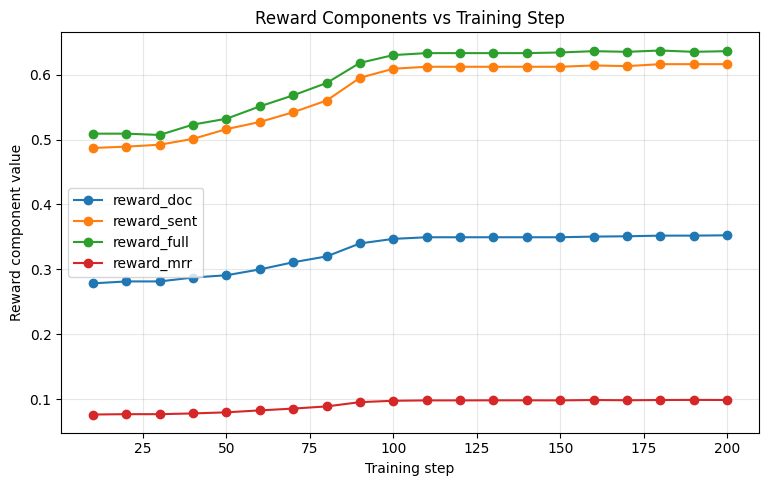

In [29]:
component_cols = ['reward_doc', 'reward_sent', 'reward_full', 'reward_mrr'] 
fig, ax = plt.subplots(figsize=(9, 5.2)) 
for col in component_cols: 
    ax.plot(df['step'], df[col], marker='o', label=col) 
ax.set_title('Reward Components vs Training Step') 
ax.set_xlabel('Training step') 
ax.set_ylabel('Reward component value') 
ax.grid(True, alpha=0.3) 
ax.legend() 
plt.show()

## 4. Stability Analysis: rolling std 
This is the checkpoint-level verification history. Therefore, here we use the rolling standard deviation of `reward` and the rolling standard deviation of `sentence_recall@10` as approximate stability indicators.

稳定性分析：这里是checkpoint 级别验证历史，所以这里用： `reward` 的滚动标准差和 `sentence_recall@10` 的滚动标准差作为近似稳定性信号。

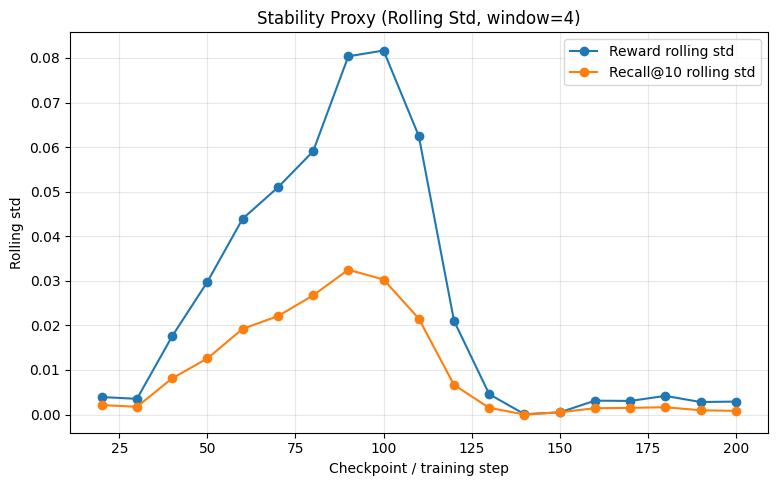

In [17]:
std_window = 4
stability = df[['step', 'reward', 'sentence_recall@10']].copy()
stability['reward_rolling_std'] = stability['reward'].rolling(std_window, min_periods=2).std()
stability['recall10_rolling_std'] = stability['sentence_recall@10'].rolling(std_window, min_periods=2).std()

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.plot(stability['step'], stability['reward_rolling_std'], marker='o', label='Reward rolling std')
ax.plot(stability['step'], stability['recall10_rolling_std'], marker='o', label='Recall@10 rolling std')
ax.set_title(f'Stability Proxy (Rolling Std, window={std_window})')
ax.set_xlabel('Checkpoint / training step')
ax.set_ylabel('Rolling std')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## 5. Validation Set Performance Curve

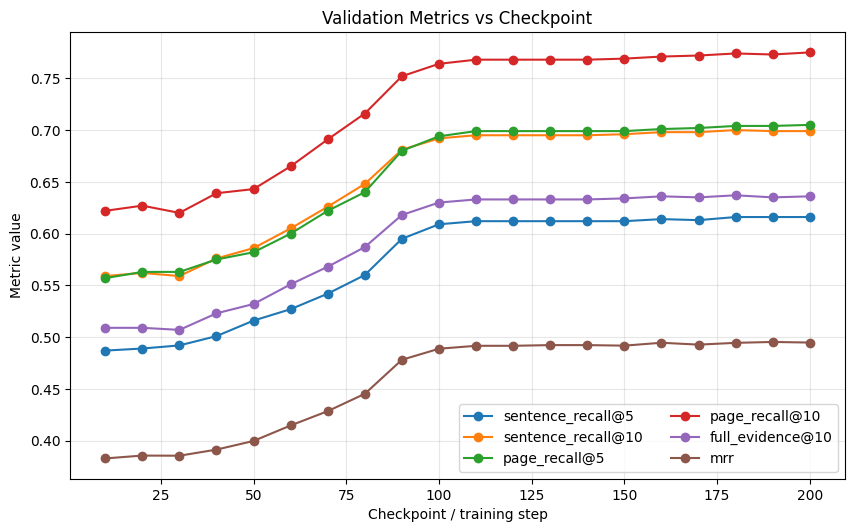

In [9]:
val_cols = ['sentence_recall@5', 'sentence_recall@10', 'page_recall@5', 'page_recall@10', 'full_evidence@10', 'mrr']
fig, ax = plt.subplots(figsize=(10, 5.8))
for col in val_cols:
    ax.plot(df['step'], df[col], marker='o', label=col)
ax.set_title('Validation Metrics vs Checkpoint')
ax.set_xlabel('Checkpoint / training step')
ax.set_ylabel('Metric value')
ax.grid(True, alpha=0.3)
ax.legend(ncol=2)
plt.show()

## 6. Query length and reward hacking

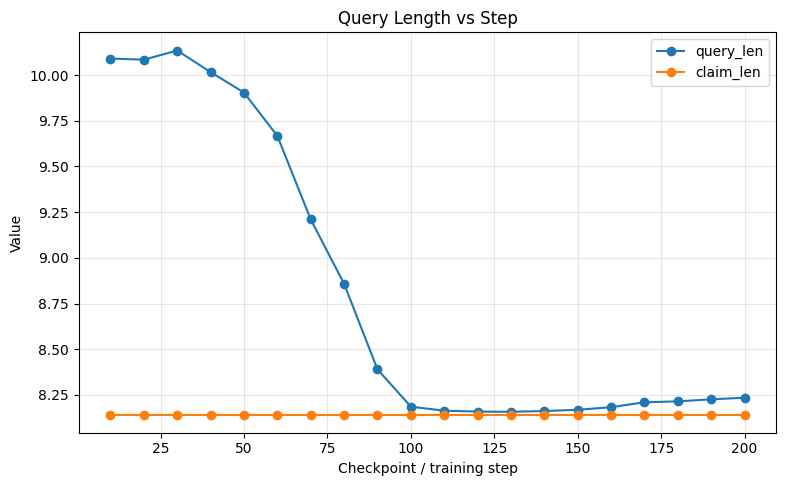

In [31]:
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.plot(df['step'], df['query_len'], marker='o', label='query_len')
ax.plot(df['step'], df['claim_len'], marker='o', label='claim_len')
#ax.plot(df['step'], df['query_growth_ratio'], marker='o', label='query_growth_ratio')
ax.set_title('Query Length vs Step')
ax.set_xlabel('Checkpoint / training step')
ax.set_ylabel('Value')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## 7. best checkpoint

In [14]:
best_reward_idx = df['reward'].idxmax()
best_recall10_idx = df['sentence_recall@10'].idxmax()
best_mrr_idx = df['mrr'].idxmax()

best_rows = pd.DataFrame([
    {'criterion': 'best_reward', **df.loc[best_reward_idx].to_dict()},
    {'criterion': 'best_sentence_recall@10', **df.loc[best_recall10_idx].to_dict()},
    {'criterion': 'best_mrr', **df.loc[best_mrr_idx].to_dict()},
]).round(4)

best_rows[['criterion', 'step', 'reward', 'sentence_recall@10', 'mrr', 'full_evidence@10', 'query_growth_ratio']]

,criterion,step,reward,sentence_recall@10,mrr,full_evidence@10,query_growth_ratio
0,best_reward,180.0,1.7039,0.700,0.4945,0.637,1.0100
1,best_sentence_recall@10,180.0,1.7039,0.700,0.4945,0.637,1.0100
2,best_mrr,190.0,1.7021,0.699,0.4954,0.635,1.0117


## 8. 可直接写进论文/报告的中文分析模板

In [33]:
start_reward = df['reward'].iloc[0]
end_reward = df['reward'].iloc[-1]
reward_gain_pct = (end_reward - start_reward) / start_reward * 100

start_r10 = df['sentence_recall@10'].iloc[0]
end_r10 = df['sentence_recall@10'].iloc[-1]
start_mrr = df['mrr'].iloc[0]
end_mrr = df['mrr'].iloc[-1]
start_full = df['full_evidence@10'].iloc[0]
end_full = df['full_evidence@10'].iloc[-1]

best_step = int(df.loc[df['sentence_recall@10'].idxmax(), 'step'])

template = f"""
During the formal GRPO training process, the validation reward exhibits a clear upward trend, increasing from {start_reward:.4f} at step {int(df['step'].iloc[0])} to {end_reward:.4f} at step {int(df['step'].iloc[-1])}, corresponding to an approximate relative improvement of {reward_gain_pct:.2f}%.
At the same time, sentence Recall@10 improves from {start_r10:.3f} to {end_r10:.3f}, while MRR increases from {start_mrr:.3f} to {end_mrr:.3f}, and full evidence@10 rises from {start_full:.3f} to {end_full:.3f}. These consistent gains indicate that the improvement in reward is not driven by a single metric, but is accompanied by simultaneous enhancements in sentence-level evidence retrieval, ranking quality, and full evidence coverage.
From the perspective of reward decomposition, both reward_sent and reward_full show noticeable growth, suggesting that the model not only becomes more effective at retrieving relevant pages, but also progressively improves its ability to identify key evidence sentences and complete evidence sets.
Furthermore, the query growth ratio remains stable, changing from {df['query_growth_ratio'].iloc[0]:.3f} to {df['query_growth_ratio'].iloc[-1]:.3f}, without exhibiting continuous expansion in query length. This indicates that there is no clear evidence of reward hacking through uncontrolled query expansion in the later stages of training.

"""
print(template)


During the formal GRPO training process, the validation reward exhibits a clear upward trend, increasing from 1.3511 at step 10 to 1.7035 at step 200, corresponding to an approximate relative improvement of 26.08%.
At the same time, sentence Recall@10 improves from 0.559 to 0.699, while MRR increases from 0.383 to 0.495, and full evidence@10 rises from 0.509 to 0.636. These consistent gains indicate that the improvement in reward is not driven by a single metric, but is accompanied by simultaneous enhancements in sentence-level evidence retrieval, ranking quality, and full evidence coverage.
From the perspective of reward decomposition, both reward_sent and reward_full show noticeable growth, suggesting that the model not only becomes more effective at retrieving relevant pages, but also progressively improves its ability to identify key evidence sentences and complete evidence sets.
Furthermore, the query growth ratio remains stable, changing from 1.263 to 1.013, without exhibiting c